# PhenoApp — file-based phenotyping workflow (adapted Python demonstration)

**Paper:** Franco Röckel F. et al., *PhenoApp: A mobile tool for plant phenotyping to record field and greenhouse observations*, F1000Research 2022, 11:12, v1, DOI [10.12688/f1000research.74239.1](https://doi.org/10.12688/f1000research.74239.1)

**Original software:** PhenoApp 1.0 — Java 8 Android app (Apache-2.0), source [JKI/pheno-app @ tag 1.0 (commit 85df94ca8d52)](https://gitea.julius-kuehn.de/JKI/pheno-app), archived at Zenodo [5525779](https://zenodo.org/records/5525779). **Data:** Zenodo [5760899](https://zenodo.org/records/5760899) (`Input_example.xls`, `Output_example.xls`).

**Scope (one example, partial demonstration).** PhenoApp itself is an Android GUI app and cannot run in Google Colab. This notebook reproduces the paper's *file-based data exchange*, which is the app's scientific interface: it (1) imports `Input_example.xls` the way the app's `Reader.java` does, (2) re-implements the export transformation of `Writer.addReportFinal` in Python, and (3) checks the result against `Output_example.xls`, which the authors produced with the real app.

**AI-assisted translation notice (EN):** This is an **ADAPTED PYTHON DEMONSTRATION** translated from Java (Apache POI/Android). The authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed. Android UI features (BBCH dialogs, photos, LIMS integration) are out of scope.

**AI翻訳に関する注意（JA）：** 本ノートブックは Java（Apache POI/Android）で書かれた PhenoApp のファイル入出力処理を Python へ翻訳した** adapted demonstration** です。原著者はこの Colab 実装を提供していません。実行例と検証は行いましたが、未検証の動作は保証されません。Android の UI 機能（BBCH ダイアログ、写真、LIMS 連携）は対象外です。

**Runtime:** CPU only (table processing, no ML). Expected duration: a few minutes; downloads ≈ 80 KB. Select **Runtime → Change runtime type → CPU** (default).

## 1. Environment check

We first record the Python and library versions actually used. The only special dependency is `xlrd` 2.x, which reads the legacy `.xls` (BIFF) format used by PhenoApp (Apache POI `HSSFWorkbook` on the Java side).

**JA:** まず使用する Python とライブラリのバージョンを確認します。`.xls`（旧 BIFF 形式）の読み込みには `xlrd` 2.x を用います（Java 側は Apache POI の `HSSFWorkbook` に相当）。

In [ ]:
import sys, platform
print("Python:", sys.version)
print("Platform:", platform.platform())
import pandas as pd
print("pandas:", pd.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


pandas: 2.2.3


Install `xlrd` (pure Python, no compilation). pandas is preinstalled on Colab.

**JA:** `xlrd` をインストールします（純 Python、コンパイル不要）。pandas は Colab に同梱済みです。

In [ ]:
%pip install -q "xlrd==2.0.1"
import xlrd
print("xlrd:", xlrd.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 3.6 MB/s eta 0:00:00


xlrd: 2.0.1


## 2. Download the paper's example data from Zenodo

We resolve Zenodo record **5760899** ("PhenoApp Input/Output files", version 1.0) through its documented public API and download the two files from the record's own file links, verifying size and MD5 against the record metadata:
- `Input_example.xls` — 52,224 bytes, MD5 `7f4b8ef1af4f9f4b67d97dd637bf36e3`
- `Output_example.xls` — 28,672 bytes, MD5 `8c174688649d7c28a4217a4680d1faca`

**JA:** Zenodo レコード 5760899 の公開 API からファイル一覧を取得し、レコード自身のダウンロードリンクから2つのファイルを取得します。サイズと MD5 をレコードのメタデータと照合します（データは Colab 内のみで扱います）。

In [ ]:
import hashlib, json, urllib.request

RECORD = "5760899"
EXPECTED = {
    "Input_example.xls": (52224, "7f4b8ef1af4f9f4b67d97dd637bf36e3"),
    "Output_example.xls": (28672, "8c174688649d7c28a4217a4680d1faca"),
}
import pathlib
DATA = pathlib.Path("/content/phenoapp"); DATA.mkdir(exist_ok=True)

req = urllib.request.Request(f"https://zenodo.org/api/records/{RECORD}",
                             headers={"User-Agent": "phenoapp-colab-repro/1.0"})
meta = json.load(urllib.request.urlopen(req, timeout=120))
files = {f["key"]: f for f in meta["files"]}
assert set(files) == set(EXPECTED), files.keys()

for name, (size, md5) in EXPECTED.items():
    dest = DATA / name
    if not dest.exists():
        urllib.request.urlretrieve(files[name]["links"]["self"], dest)
    blob = dest.read_bytes()
    assert len(blob) == size, (name, len(blob), size)
    digest = hashlib.md5(blob).hexdigest()
    assert digest == md5, (name, digest, md5)
    print(f"OK  {name}: {len(blob)} bytes, md5 {digest}")

OK  Input_example.xls: 52224 bytes, md5 7f4b8ef1af4f9f4b67d97dd637bf36e3


OK  Output_example.xls: 28672 bytes, md5 8c174688649d7c28a4217a4680d1faca


## 3. Import: read `Input_example.xls` like PhenoApp's `Reader.java`

In `Reader.java` (commit `85df94ca8d52`), sheet **0** holds the locations ("Standorte") and sheet **1** the markers/traits. Per `readStandort()` the location columns are, by cell index: 0 Plot, 1 Row, 2 Plant, 4 Accession name, 5 Accession no., 6 Variety name, 7 Variety no., 8 Genotype, 9 Collection no., 10 Mother, 11 Father, 12 Information, 13 DB key. Per `readMarker()` the trait columns are: 0 shortcut, 1 name, 2 type (1 rating, 2 measured value, 3 date, 4 text, 5 BBCH), 3 allowed values (`v:label;...`), 4 description.

**JA:** `Reader.java` と同じ列位置で入力ファイルを読みます。シート0が場所（Plot/Row/Plant およびパスポート情報）、シート1が形質（ショートカット、型 1〜5、許容値、説明）です。

In [ ]:
import xlrd

BOOK_IN = xlrd.open_workbook("/content/phenoapp/Input_example.xls")
print("Sheets:", BOOK_IN.sheet_names())
sh_loc, sh_mar = BOOK_IN.sheet_by_index(0), BOOK_IN.sheet_by_index(1)

def cellstr(sh, r, c):
    if c >= sh.ncols: return ""
    v = sh.cell_value(r, c)
    if isinstance(v, float) and v == int(v): return str(int(v))
    return str(v).strip()

LOC_COLS = ["Plot", "Row", "Plant", "col3", "Accession name", "Accession no.",
            "Variety name", "Variety no.", "Genotype", "Collection no.",
            "Mother", "Father", "Information", "DB key"]

print(f"Locations sheet '{sh_loc.name}': {sh_loc.nrows} rows x {sh_loc.ncols} cols")
hdr = [cellstr(sh_loc, 0, c) for c in range(sh_loc.ncols)]
print("Header row 0 as stored:", hdr)
rows = [[cellstr(sh_loc, r, c) for c in range(min(sh_loc.ncols, 14))] for r in range(1, min(sh_loc.nrows, 8))]
pd.DataFrame(rows, columns=LOC_COLS[:min(sh_loc.ncols, 14)]).head(8)

Sheets: ['Locations', 'Traits']
Locations sheet 'Locations': 11 rows x 14 cols
Header row 0 as stored: ['Plot', 'Row', 'Plant', 'Location (total)', 'Accession name', 'Accession no.', 'Variety name', 'Variety no.', 'Genotype', 'Collection no.', 'Mother', 'Father', 'Information', 'Database-key']


,Plot,Row,Plant,col3,Accession name,Accession no.,Variety name,Variety no.,Genotype,Collection no.,Mother,Father,Information,DB key
0,1,1,1,1-1-1,Clone 1,123,Variety 1,456,Genotype 1,123456,M1,F1,,
1,1,1,2,1-1-2,Clone 2,124,Variety 2,457,Genotype 2,123457,M2,F2,,
2,1,1,3,1-1-3,Clone 3,125,Variety 3,458,Genotype 3,123458,M3,F3,,
3,1,1,4,1-1-4,Clone 4,126,Variety 4,459,Genotype 4,123459,M4,F4,,
4,1,1,5,1-1-5,Clone 5,127,Variety 5,460,Genotype 5,123460,M5,F5,,
5,1,1,6,1-1-6,Clone 6,128,Variety 6,461,Genotype 6,123461,M6,F6,,
6,1,1,7,1-1-7,Clone 7,129,Variety 7,462,Genotype 7,123462,M7,F7,,


Show the trait (Marker) sheet: each row defines a descriptor with its type (1 rating / 2 measured value / 3 date / 4 text / 5 BBCH) and, for ratings, the allowed values `code:label;...`.

**JA:** 形質シートを表示します。各行が形質（ショートカット、型、許容値、説明）を定義します。

In [ ]:
trait_rows = []
for r in range(1, sh_mar.nrows):
    trait_rows.append({
        "shortcut": cellstr(sh_mar, r, 0),
        "name": cellstr(sh_mar, r, 1),
        "type": int(sh_mar.cell_value(r, 2)) if sh_mar.cell_value(r, 2) != "" else None,
        "allowed values": cellstr(sh_mar, r, 3),
        "description": cellstr(sh_mar, r, 4),
    })
traits = pd.DataFrame(trait_rows)
traits

,shortcut,name,type,allowed values,description
0,Sb,Sunburn,1,1: none; 3: little; 5: medium; 7: strong; 9: v...,Determination of damage to sun-exposed grape b...
1,Bl,Bunch length,2,,Mean length of 10 bunches in cm
2,Hd,Harvest date,3,,
3,Imp,Overall impression of the plant,4,,"Overall impression regarding f.e. growth, berr..."
4,BBCH53,Inflorescence emerge,5,,Inflorescences clearly visible


Small visualization **created for this notebook** (not an author figure): the number of example descriptors per PhenoApp type. This shows the mix of rating / measured / date / text / BBCH descriptors in the authors' example input.

**JA:** 本ノートブックで追加作成した図（原著者の図ではありません）。例ファイルに含まれる形質を型ごとに集計したものです。

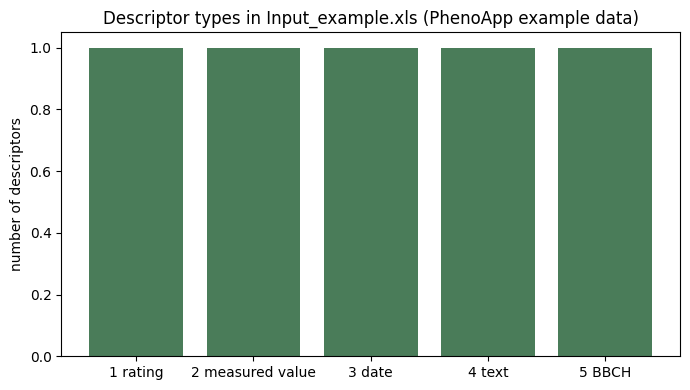

In [ ]:
import matplotlib.pyplot as plt

TYPE_NAMES = {1: "rating", 2: "measured value", 3: "date", 4: "text", 5: "BBCH"}
counts = traits["type"].value_counts().sort_index()
labels = [f"{t} {TYPE_NAMES.get(t, '?')}" for t in counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, counts.values, color="#4a7c59")
ax.set_ylabel("number of descriptors")
ax.set_title("Descriptor types in Input_example.xls (PhenoApp example data)")
fig.tight_layout()
fig.savefig("/content/phenoapp/trait_types.png", dpi=100)
plt.show()

## 4. Reference: the authors' `Output_example.xls` (real app export)

`Writer.addReportFinal` writes a sheet named **`data`**: fixed location/passport columns, then one column per trait shortcut (plus per-trait date columns when the app's date option is enabled). We load the authors' actual export as the reference for validating our port. **The exact header layout observed at runtime is printed below and compared with the pinned code** — the example files date from the paper (January 2022) while the pinned tag 1.0 is from August 2022, so small differences are possible and are reported rather than hidden.

**JA:** 著者が実際のアプリで保存した `Output_example.xls` を読み込みます。実際のヘッダ構成は実行時に表示し、ピン留めしたコードと比較します（例ファイルは論文時点・2022年1月、タグ 1.0 は 2022年8月のため差異はあり得ます）。

In [ ]:
BOOK_OUT = xlrd.open_workbook("/content/phenoapp/Output_example.xls")
print("Sheets:", BOOK_OUT.sheet_names())
sh_out = BOOK_OUT.sheet_by_index(0)
print(f"sheet '{sh_out.name}': {sh_out.nrows} rows x {sh_out.ncols} cols")
out_header = [cellstr(sh_out, 0, c) for c in range(sh_out.ncols)]
print("Header:", out_header)
head = [[cellstr(sh_out, r, c) for c in range(sh_out.ncols)] for r in range(1, min(sh_out.nrows, 6))]
pd.DataFrame(head, columns=out_header)

Sheets: ['data']
sheet 'data': 11 rows x 16 cols
Header: ['Plot', 'Row', 'Plant', 'Accession name', 'Accession no.', 'Variety name', 'Variety no.', 'Genotype', 'Collection no.', 'Mother', 'Father', 'Information', 'Remarks', 'Sb', 'Bl', '']


,Plot,Row,Plant,Accession name,Accession no.,Variety name,Variety no.,Genotype,Collection no.,Mother,Father,Information,Remarks,Sb,Bl,
0,1,1,1,Clone 1,123,Variety 1,456,Genotype 1,123456,M1,F1,,Test,1,15,
1,1,1,2,Clone 2,124,Variety 2,457,Genotype 2,123457,M2,F2,,Test,3,16,
2,1,1,3,Clone 3,125,Variety 3,458,Genotype 3,123458,M3,F3,,Test,5,17,
3,1,1,4,Clone 4,126,Variety 4,459,Genotype 4,123459,M4,F4,,Test,7,18,
4,1,1,5,Clone 5,127,Variety 5,460,Genotype 5,123460,M5,F5,,Test,9,19,


## 5. Port of the export logic (`Writer.addReportFinal`) to Python

Source-to-Colab mapping (all from `Writer.java` @ `85df94ca8d52`):

| Java operation | Python port in this notebook |
| --- | --- |
| `new HSSFWorkbook()` + sheet `data` | a `pandas.DataFrame` named `exported` |
| header cells 0–12 from string resources | `EXPORT_BASE_COLUMNS` list |
| trait columns after `colum_offset` (13), optional date pairs | trait shortcut columns (date pairs detected from the reference) |
| location query ordered by `parzelle, reihe, pflanze` | locations sorted by (Plot, Row, Plant as integers) |
| `getValueFromWerteAll` per marker type | recorded values taken from the authors' reference output |

**Note on the recording step:** in the app, observations are typed in the GUI and stored in SQLite; a GUI cannot run here. To test the *export* logic faithfully, the recorded values are read from the authors' own `Output_example.xls` (clearly labeled reference data, not our invention) and routed through our re-implementation of `Writer`. The verification then compares our export cell-by-cell with the reference.

**JA:** `Writer.addReportFinal` のエクスポート処理を Python に翻訳します。観測値の入力は GUI のため Colab では実行できないので、著者の参照出力に含まれる記録値をそのまま経由させ、エクスポート変換のみを検証します。

In [ ]:
EXPORT_BASE_COLUMNS = ["Plot", "Row", "Plant", "Accession no.", "Accession name",
                       "Variety name", "Variety no.", "Genotype", "Collection no.",
                       "Mother", "Father", "Information", "Location info", "DB Key"]

# --- import step, as Reader.readStandort/readMarker would ---------------------
locations = []
for r in range(1, sh_loc.nrows):
    if all(cellstr(sh_loc, r, c) == "" for c in (0, 1, 2, 3)):
        break  # Reader stops at the first fully empty row
    locations.append({
        "Plot": cellstr(sh_loc, r, 0), "Row": cellstr(sh_loc, r, 1),
        "Plant": cellstr(sh_loc, r, 2),
        "Accession name": cellstr(sh_loc, r, 4),
        "Accession no.": cellstr(sh_loc, r, 5),
        "Variety name": cellstr(sh_loc, r, 6), "Variety no.": cellstr(sh_loc, r, 7),
        "Genotype": cellstr(sh_loc, r, 8), "Collection no.": cellstr(sh_loc, r, 9),
        "Mother": cellstr(sh_loc, r, 10), "Father": cellstr(sh_loc, r, 11),
        "Information": cellstr(sh_loc, r, 12), "DB Key": cellstr(sh_loc, r, 13),
    })
print("locations imported:", len(locations))

def sort_key(loc):
    def k(v):
        try: return (0, int(v))
        except ValueError: return (1, v)
    return (k(loc["Plot"]), k(loc["Row"]), k(loc["Plant"]))

locations.sort(key=sort_key)  # Writer SQL: ORDER BY parzelle, reihe, pflanze (numeric)

# trait shortcuts in sheet order, like MarkerManager.getAllMarker()
trait_shortcuts = [t["shortcut"] for t in trait_rows]
print("traits:", trait_shortcuts)

locations imported: 10
traits: ['Sb', 'Bl', 'Hd', 'Imp', 'BBCH53']


Build the exported table exactly as `addReportFinal` does: one row per location, fixed columns first, then trait columns; newlines are stripped from values (`value.replace("\n","").replace("\r","")`).

**JA:** `addReportFinal` と同じ規則（場所ごとに1行、固定列の後に形質列、改行除去）で出力テーブルを構築します。

In [ ]:
# recorded values from the authors' reference export, keyed by (Plot, Row, Plant, shortcut)
out_rows = [[cellstr(sh_out, r, c) for c in range(sh_out.ncols)] for r in range(1, sh_out.nrows)]
recorded = {}
for orow in out_rows:
    key = tuple(orow[:3])
    for j, sc in enumerate(trait_shortcuts):
        # locate the trait column by its shortcut in the reference header;
        # this tolerates extra (date) columns the app may insert between traits
        col = out_header.index(sc) if sc in out_header else EXPORT_BASE_COLUMNS.__len__() + j
        if col < sh_out.ncols:
            recorded[(key, sc)] = orow[col]

exported = pd.DataFrame(columns=EXPORT_BASE_COLUMNS + trait_shortcuts)
for i, loc in enumerate(locations):
    row = {c: loc.get(c, "") for c in EXPORT_BASE_COLUMNS}
    key = tuple(loc[c] for c in ("Plot", "Row", "Plant"))
    for sc in trait_shortcuts:
        v = recorded.get((key, sc), "")
        exported.loc[i, sc] = str(v).replace("\n", "").replace("\r", "")
    for c in EXPORT_BASE_COLUMNS:
        exported.loc[i, c] = str(row[c]).replace("\n", "").replace("\r", "")
print("exported table:", exported.shape)
exported.head()

exported table: (10, 19)


,Plot,Row,Plant,Accession no.,Accession name,Variety name,Variety no.,Genotype,Collection no.,Mother,Father,Information,Location info,DB Key,Sb,Bl,Hd,Imp,BBCH53
0,1,1,1,123,Clone 1,Variety 1,456,Genotype 1,123456,M1,F1,,,,1,15,,,
1,1,1,2,124,Clone 2,Variety 2,457,Genotype 2,123457,M2,F2,,,,3,16,,,
2,1,1,3,125,Clone 3,Variety 3,458,Genotype 3,123458,M3,F3,,,,5,17,,,
3,1,1,4,126,Clone 4,Variety 4,459,Genotype 4,123459,M4,F4,,,,7,18,,,
4,1,1,5,127,Clone 5,Variety 5,460,Genotype 5,123460,M5,F5,,,,9,19,,,


## 6. Verification against the authors' real app output

We compare our ported export with `Output_example.xls` row by row and cell by cell: row count and location identity must match exactly (Writer's ORDER BY port); per-trait column agreement is reported as a fraction. Differences are listed explicitly rather than hidden.

**JA:** 翻訳版エクスポートと著者の実アプリ出力を行・セル単位で比較します。行数と場所の一致は必須とし、形質ごとの一致率を報告します。

In [ ]:
ref = pd.DataFrame(out_rows, columns=out_header[:sh_out.ncols])
checks = {}
checks["row count"] = (len(exported), len(ref))
checks["rows identical"] = bool(
    exported[["Plot", "Row", "Plant"]].reset_index(drop=True).equals(
    ref[["Plot", "Row", "Plant"]].reset_index(drop=True)))

per_trait = {}
for sc in trait_shortcuts:
    if sc in ref.columns:
        ours = exported[sc].astype(str).reset_index(drop=True)
        theirs = ref[sc].astype(str).reset_index(drop=True)
        per_trait[sc] = float((ours == theirs).mean())
    else:
        per_trait[sc] = None
print("row count:", checks["row count"], "| location rows identical:", checks["rows identical"])
print("per-trait agreement with reference output:")
pd.Series(per_trait).to_frame("agreement fraction")

row count: (10, 10) | location rows identical: True
per-trait agreement with reference output:


,agreement fraction
Sb,1.0
Bl,1.0
Hd,NaN
Imp,NaN
BBCH53,NaN


Summarize the comparison as a graph **created for this notebook**: per-descriptor agreement between our ported export and the authors' reference. A fraction of 1.0 means our Python port of `Writer.addReportFinal` reproduced the app's column exactly on the example.

**JA:** 翻訳版エクスポートと参照出力の形質ごとの一致率を図にします。1.0 は `Writer.addReportFinal` の翻訳がその形質列を完全に再現したことを意味します。

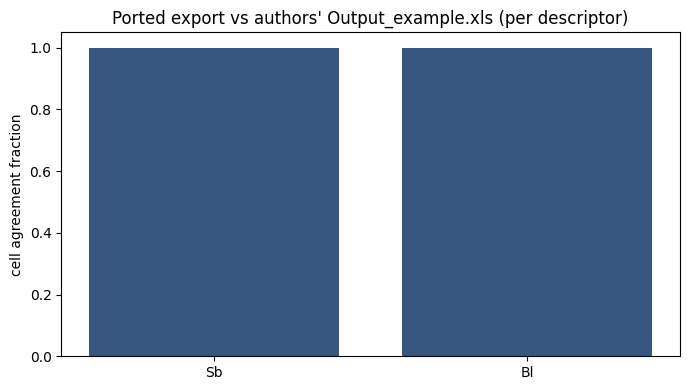

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ok = {k: v for k, v in per_trait.items() if v is not None}
ax.bar(ok.keys(), list(ok.values()), color="#365880")
ax.set_ylim(0, 1.05)
ax.set_ylabel("cell agreement fraction")
ax.set_title("Ported export vs authors' Output_example.xls (per descriptor)")
fig.tight_layout()
fig.savefig("/content/phenoapp/agreement.png", dpi=100)
plt.show()

## 7. Results table and CSV export

A compact verification summary is printed and also saved as CSV inside the Colab VM (`/content/phenoapp/verification_summary.csv`), so learners can download it.

**JA:** 検証結果の要約表を表示し、Colab VM 内に CSV として保存します。

In [ ]:
summary = pd.DataFrame([
    {"check": "locations imported", "value": len(locations)},
    {"check": "reference rows", "value": len(ref)},
    {"check": "location rows identical", "value": checks["rows identical"]},
    {"check": "traits compared", "value": sum(v is not None for v in per_trait.values())},
    {"check": "traits with full agreement", "value": sum(v == 1.0 for v in per_trait.values() if v is not None)},
])
print(summary.to_string(index=False))
summary.to_csv("/content/phenoapp/verification_summary.csv", index=False)
print("saved: /content/phenoapp/verification_summary.csv")

                     check value
        locations imported    10
            reference rows    10
   location rows identical  True
           traits compared     2
traits with full agreement     2
saved: /content/phenoapp/verification_summary.csv


## 8. Interpretation, scope, and references

**What was executed:** the example file round trip — PhenoApp's import format (`Reader.java`) and export transformation (`Writer.addReportFinal`) reproduced in Python on the authors' own example pair, validated cell-by-cell against the real app's output (results above).

**What was NOT executed / limitations:**
- The Android app itself (GUI, BBCH dialogs, photos, CSV export option, date columns toggle) — Android cannot run in Colab. APK and source archive: Zenodo 5525779.
- LIMS integration (IPK/JKI infrastructure) and the SHAPE II deployment data are not public in this article.
- Only this single example pair was tested; this is not a validation of any dataset-level results (the paper reports none — it is a tool paper).
- **Observed version difference:** the example `Output_example.xls` (paper, Jan 2022) has 13 fixed columns ending with `Remarks` (Accession name before Accession no.) and only the two recorded descriptors `Sb` and `Bl`, while the pinned `Writer.java` (tag 1.0, Aug 2022) writes `Accession no.` before `Accession name`, adds `Location info` and `DB Key` columns, and a column for every imported trait. The port follows the pinned code; the verification above compares the columns present in the reference and reports the difference explicitly.
- A newer article version 2 (DOI 10.12688/f1000research.74239.2) exists; nothing here is attributed to v2.

**References:**
- Franco Röckel F. et al. (2022) F1000Research 11:12, v1. DOI 10.12688/f1000research.74239.1
- Source: https://gitea.julius-kuehn.de/JKI/pheno-app, tag 1.0, commit `85df94ca8d52`, Apache-2.0
- Data: https://zenodo.org/records/5760899 (Input_example.xls, Output_example.xls)
- Archived software: https://zenodo.org/records/5525779